## Imports



In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import holidays
import missingno as msno 
import seaborn as sns

## Load And Normalize Data

This block loads the single-index household dataset, drops the local `cet_cest_timestamp` column, parses `utc_timestamp` as datetime, and keeps only `utc_timestamp` plus residential measurement columns for analysis.

In [26]:
df = pd.read_csv("data/household_data_15min_singleindex.csv")
df = df.drop(columns=["cet_cest_timestamp"])
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])

residential_cols = [col for col in df.columns if "residential" in col.lower()]
df = df[["utc_timestamp"] + residential_cols]

## Build Time-Based Features

This block prints the time span covered by the dataset and derives calendar features from the timestamp column, including year, month, day, hour, minute, weekday, weekend and weekday flags, plus a Baden-Wuerttemberg public holiday indicator.

In [27]:
# show the first and last timestamps in the dataset to get an idea of the time range of the data

print(f"First timestamp: {df.utc_timestamp.min()}")
print(f"Last timestamp: {df.utc_timestamp.max()}")

df["year"] = df.utc_timestamp.dt.year
df["month"] = df.utc_timestamp.dt.month
df["day"] = df.utc_timestamp.dt.day
df["hour"] = df.utc_timestamp.dt.hour
df["minute"] = df.utc_timestamp.dt.minute
df["weekday"] = df.utc_timestamp.dt.weekday # Monday=0, Sunday=6
df["is_weekend"] = df["weekday"] >= 5
df["is_weekday"] = df["weekday"] < 5

# Add Germany (Baden-Wuerttemberg) holiday flag 

german_holidays = holidays.CountryHoliday("DE", prov="BW")
holiday_dates = pd.to_datetime(list(german_holidays.keys()))
df["is_holiday"] = df["utc_timestamp"].dt.normalize().isin(holiday_dates)

First timestamp: 2014-12-11 17:45:00+00:00
Last timestamp: 2019-05-01 22:00:00+00:00


## Convert Cumulative Readings To Interval Consumption

All appliance/grid columns contain cumulative kWh meter readings. Taking the row-wise difference converts them to per-interval consumption values. Negative differences (meter resets or data gaps) are replaced with `NaN` rather than kept as invalid negatives.

In [28]:
time_cols = {"utc_timestamp", "year", "month", "day", "hour", "minute", "weekday", "is_weekend", "is_weekday", "is_holiday"}
energy_cols = [c for c in df.columns if c not in time_cols]

df[energy_cols] = df[energy_cols].diff()

print(f"Converted {len(energy_cols)} columns from cumulative to interval values.")
df[energy_cols].describe()

Converted 39 columns from cumulative to interval values.


,DE_KN_residential1_dishwasher,DE_KN_residential1_freezer,DE_KN_residential1_grid_import,DE_KN_residential1_heat_pump,DE_KN_residential1_pv,DE_KN_residential1_washing_machine,DE_KN_residential2_circulation_pump,DE_KN_residential2_dishwasher,DE_KN_residential2_freezer,DE_KN_residential2_grid_import,...,DE_KN_residential5_grid_import,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine
count,63377.000000,51579.00000,63486.000000,63486.000000,63486.000000,63380.000000,79290.000000,76529.000000,40999.000000,63189.000000,...,123210.000000,58253.000000,94160.000000,86132.000000,56242.000000,61382.000000,66754.000000,86132.000000,86132.000000,59135.000000
mean,0.004238,0.00839,0.143281,0.160878,0.260243,0.005054,0.010958,0.007792,0.003427,0.071143,...,0.071210,0.010365,0.005060,0.011038,0.001708,0.002390,0.051580,0.085314,0.237953,0.001330
std,0.034291,0.00596,0.115451,0.246406,0.480116,0.038209,0.013229,0.051328,0.003902,0.094229,...,0.075835,0.009249,0.032005,0.007280,0.010282,0.005235,0.160373,0.100080,0.454370,0.009894
min,0.000000,0.00000,0.029000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.00200,0.090000,0.000000,0.000000,0.000000,0.001000,0.000000,0.000000,0.030000,...,0.030000,0.000000,0.000000,0.007000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.00900,0.110000,0.010000,0.000000,0.000000,0.003000,0.000000,0.002000,0.043000,...,0.050000,0.011000,0.000000,0.007000,0.000000,0.001000,0.000000,0.058000,0.000000,0.000000
75%,0.000000,0.01400,0.145000,0.269000,0.263000,0.000000,0.018000,0.000000,0.007000,0.070000,...,0.080000,0.015000,0.000000,0.019000,0.000000,0.001000,0.010000,0.144000,0.211000,0.000000
max,0.470000,0.02900,1.663000,2.410000,2.129000,0.545000,0.077000,0.559000,0.241000,2.064000,...,1.235000,0.035000,0.514000,0.048000,0.457000,0.110000,0.995000,0.941000,2.000000,0.378000


## Visualize Missing Values

This block uses missingno to draw a matrix of present and missing values across the dataframe, which helps reveal gaps, concentrations of missingness, and potential data quality issues.

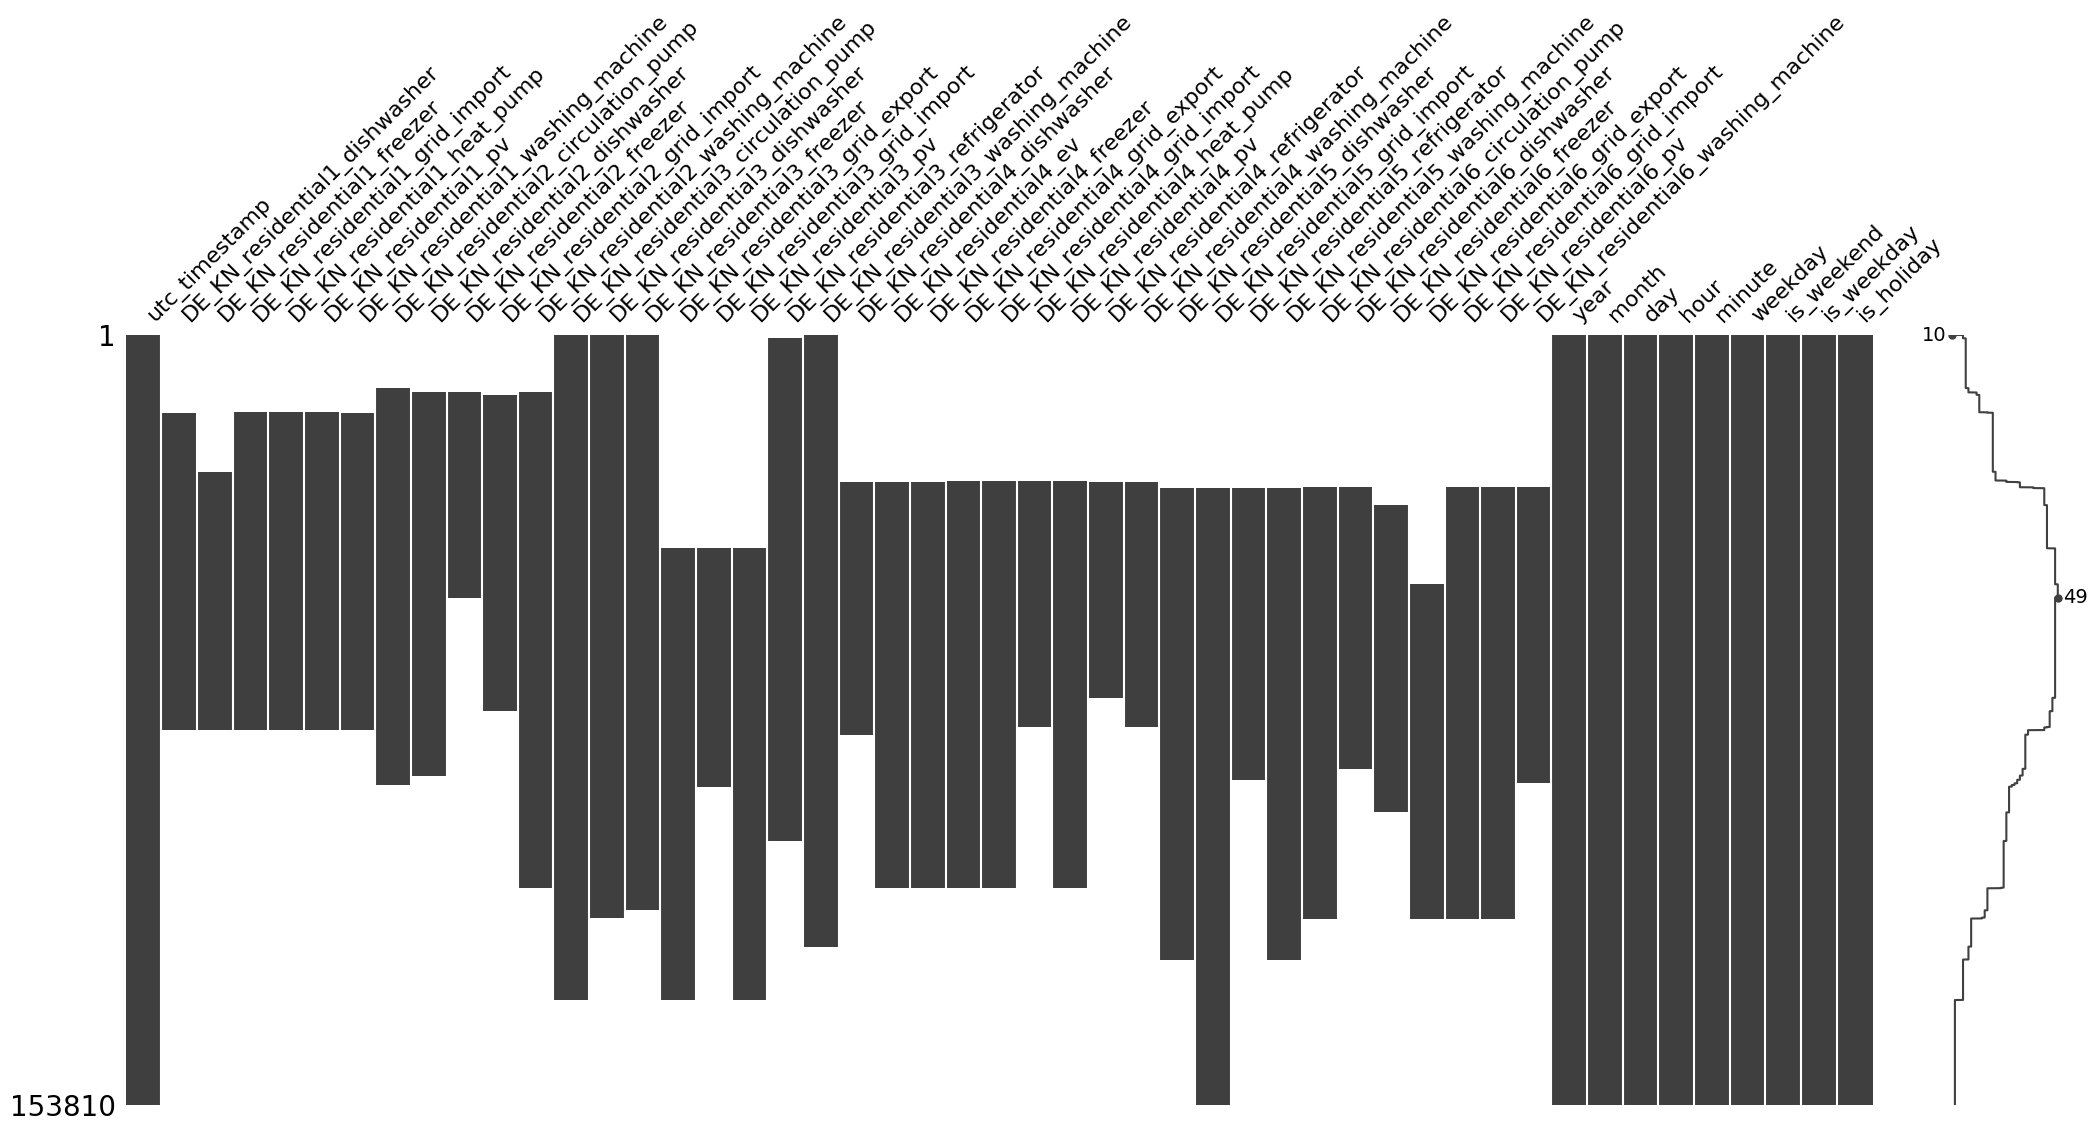

In [29]:
msno.matrix(df)
plt.show()

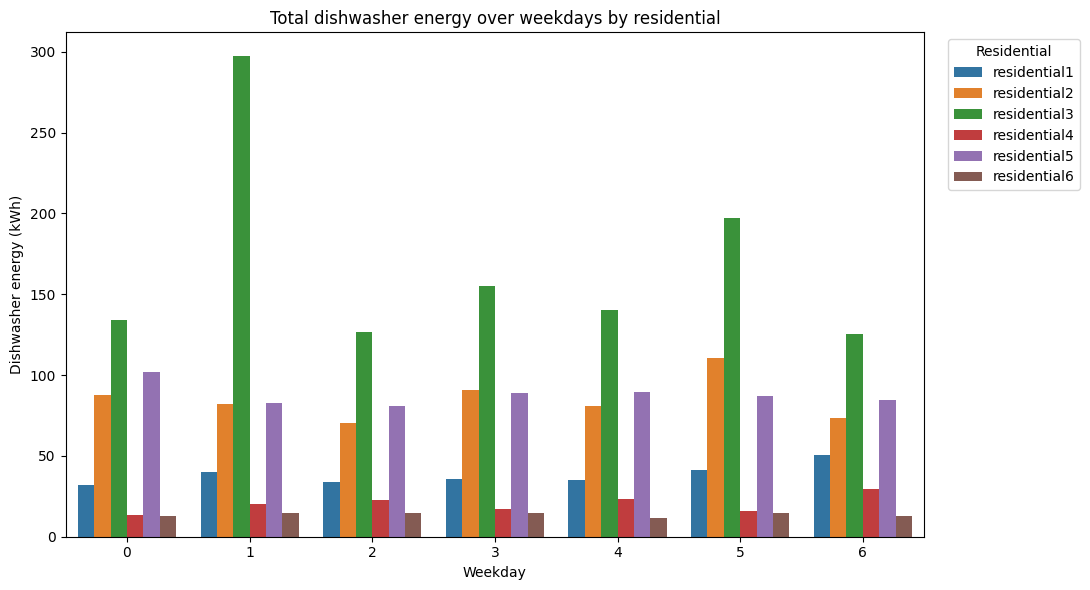

In [30]:
# sum every column with "dishwasher" in the name and plot total kWh by weekday

dishwasher_cols = df.filter(regex=r"(?i)dishwasher").columns.tolist()

dishwasher_long = (
    df[["weekday"] + dishwasher_cols]
    .melt(id_vars="weekday", var_name="column", value_name="kWh")
)

dishwasher_long["residential"] = (
    dishwasher_long["column"]
    .str.extract(r"(residential\d+)", expand=False)
    .fillna(dishwasher_long["column"])
)

weekday_kwh = (
    dishwasher_long
    .groupby(["weekday", "residential"], as_index=False)["kWh"]
    .sum()
)

plt.figure(figsize=(11, 6))
sns.barplot(x="weekday", y="kWh", hue="residential", data=weekday_kwh)
plt.title("Total dishwasher energy over weekdays by residential")
plt.xlabel("Weekday")
plt.ylabel("Dishwasher energy (kWh)")
plt.legend(title="Residential", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


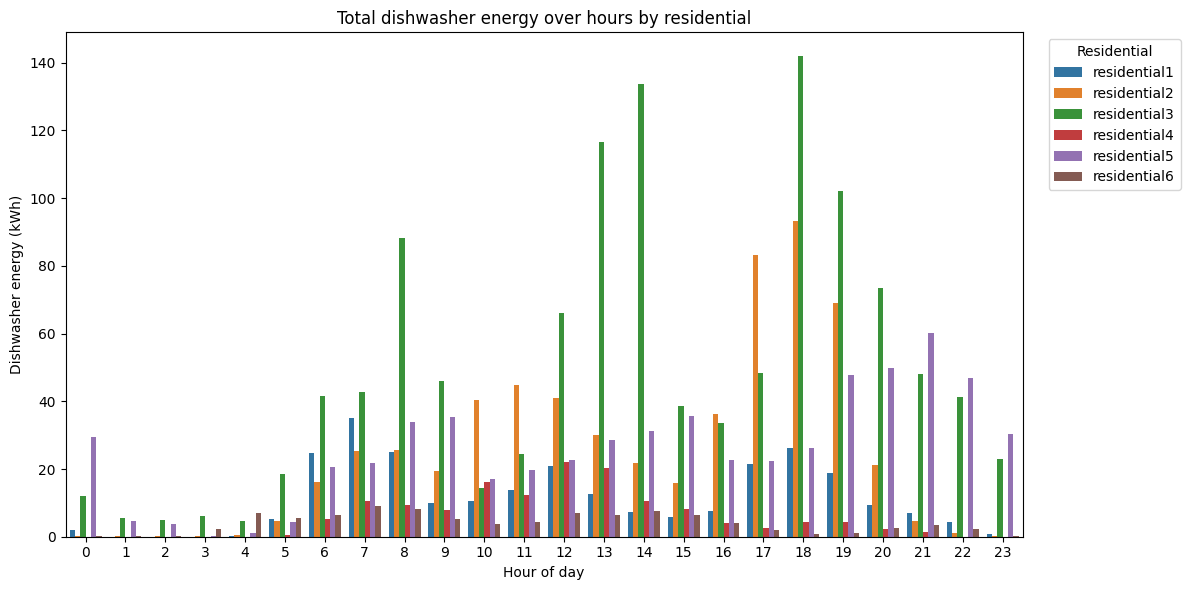

In [31]:
# duplicate the dishwasher plot for hours of day (kWh), colored by residential

dishwasher_cols = df.filter(regex=r"(?i)dishwasher").columns.tolist()

if not dishwasher_cols:
    raise ValueError("No columns matching 'dishwasher' were found.")

dishwasher_hour_long = (
    df[["hour"] + dishwasher_cols]
    .melt(id_vars="hour", var_name="column", value_name="kWh")
)

dishwasher_hour_long["residential"] = (
    dishwasher_hour_long["column"]
    .str.extract(r"(residential\d+)", expand=False)
    .fillna(dishwasher_hour_long["column"])
)

hour_kwh = (
    dishwasher_hour_long
    .groupby(["hour", "residential"], as_index=False)["kWh"]
    .sum()
    .sort_values(["hour", "residential"])
)

plt.figure(figsize=(12, 6))
sns.barplot(x="hour", y="kWh", hue="residential", data=hour_kwh)
plt.title("Total dishwasher energy over hours by residential")
plt.xlabel("Hour of day")
plt.ylabel("Dishwasher energy (kWh)")
plt.legend(title="Residential", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [32]:
# create a new column for each residential with total energy consumption
# load = grid_import - grid_export + pv (use available columns if some are missing)

# remove "DE_KN_" from all columns (safe if already removed)
df.columns = df.columns.str.replace("DE_KN_", "", regex=False)

residential_ids = sorted({c.split("_")[0] for c in df.columns if c.startswith("residential")})

for rid in residential_ids:
    import_col = f"{rid}_grid_import"
    export_col = f"{rid}_grid_export"
    pv_col = f"{rid}_pv"

    load = pd.Series(0.0, index=df.index)
    used = []

    if import_col in df.columns:
        load = load + df[import_col]
        used.append(import_col)
    if export_col in df.columns:
        load = load - df[export_col]
        used.append(export_col)
    if pv_col in df.columns:
        load = load + df[pv_col]
        used.append(pv_col)

    if used:
        df[f"{rid}_load"] = load
        missing = [col for col in [import_col, export_col, pv_col] if col not in df.columns]
        if missing:
            print(f"{rid}: computed with missing columns {missing}")
    else:
        print(f"Skipping {rid}: none of import/export/pv columns exist")

df


residential1: computed with missing columns ['residential1_grid_export']
residential2: computed with missing columns ['residential2_grid_export', 'residential2_pv']
residential5: computed with missing columns ['residential5_grid_export', 'residential5_pv']


,utc_timestamp,residential1_dishwasher,residential1_freezer,residential1_grid_import,residential1_heat_pump,residential1_pv,residential1_washing_machine,residential2_circulation_pump,residential2_dishwasher,residential2_freezer,...,weekday,is_weekend,is_weekday,is_holiday,residential1_load,residential2_load,residential3_load,residential4_load,residential5_load,residential6_load
0,2014-12-11 17:45:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,False,True,False,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-12-11 18:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,False,True,False,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-12-11 18:15:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,False,True,False,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-12-11 18:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,False,True,False,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-12-11 18:45:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,False,True,False,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153805,2019-05-01 21:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,False,True,False,NaN,NaN,NaN,NaN,0.085,NaN
153806,2019-05-01 21:15:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,False,True,False,NaN,NaN,NaN,NaN,0.095,NaN
153807,2019-05-01 21:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,False,True,False,NaN,NaN,NaN,NaN,0.094,NaN
153808,2019-05-01 21:45:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,False,True,False,NaN,NaN,NaN,NaN,0.096,NaN


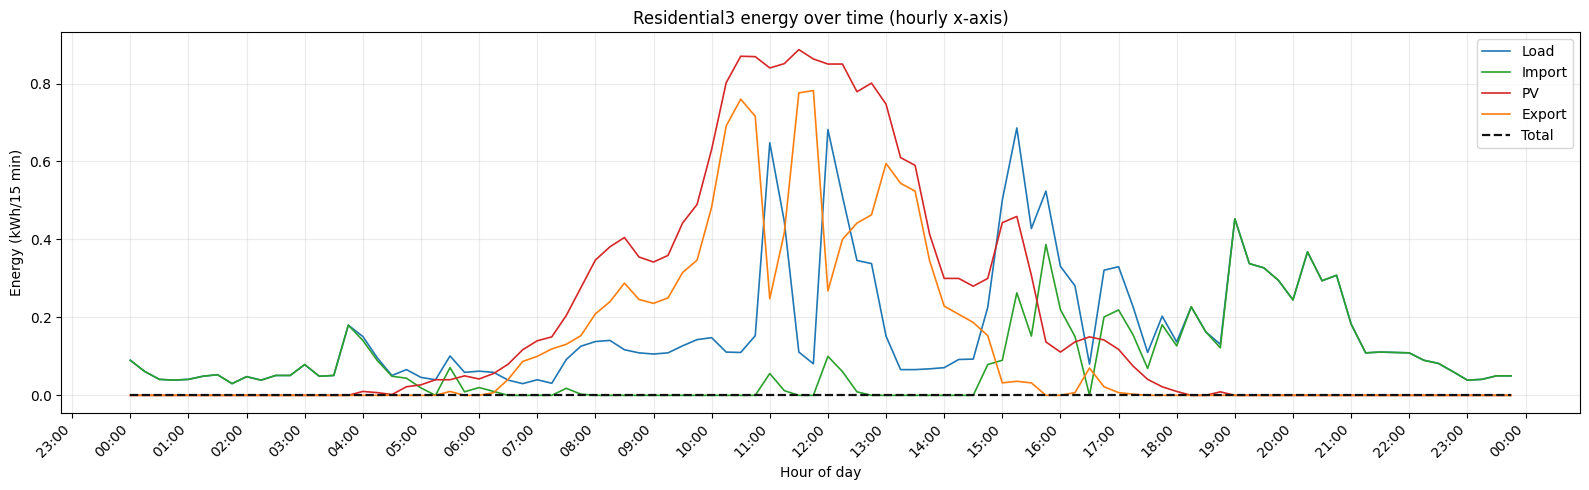

In [39]:
# plot residential1 load, import, and export over a long timeframe

import matplotlib.dates as mdates

# Support both stripped and original column naming conventions
col_candidates = {
    "Load": ["residential3_load"],
    "Import": ["residential3_grid_import"],
    "PV": ["residential3_pv"],
    "Export": ["residential3_grid_export"],
}

series_cols = {}
for label, candidates in col_candidates.items():
    series_cols[label] = next((c for c in candidates if c in df.columns), None)

available_cols = [c for c in series_cols.values() if c is not None]

plot_df = df[["utc_timestamp"] + available_cols].copy()
plot_df["utc_timestamp"] = pd.to_datetime(plot_df["utc_timestamp"], errors="coerce")
plot_df = plot_df.dropna(subset=["utc_timestamp"]).sort_values("utc_timestamp")

# plot timeframe only for one day in the summer to check if the data looks reasonable (should show 96 intervals for 15min data)
summer_df = plot_df[(plot_df["utc_timestamp"] >= "2016-06-01") & (plot_df["utc_timestamp"] < "2016-06-02")].copy()

# calculate total = import + pv - export - load
total_series = pd.Series(0.0, index=summer_df.index)
if series_cols["Import"] is not None:
    total_series = total_series + summer_df[series_cols["Import"]]
if series_cols["PV"] is not None:
    total_series = total_series + summer_df[series_cols["PV"]]
if series_cols["Export"] is not None:
    total_series = total_series - summer_df[series_cols["Export"]]
if series_cols["Load"] is not None:
    total_series = total_series - summer_df[series_cols["Load"]]
summer_df["Total"] = total_series

plt.figure(figsize=(16, 5))
colors = {"Load": "#1f77b4", "Import": "#2ca02c", "PV": "#d62728", "Export": "#ff7f0e", "Total": "#111111"}

for label in ["Load", "Import", "PV", "Export"]:
    col = series_cols[label]
    if col is None:
        plt.plot([], [], color=colors[label], label=f"{label} (missing)")
    else:
        plt.plot(summer_df["utc_timestamp"], summer_df[col], color=colors[label], linewidth=1.2, label=label)

plt.plot(summer_df["utc_timestamp"], summer_df["Total"], color=colors["Total"], linewidth=1.6, linestyle="--", label="Total")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.title("Residential3 energy over time (hourly x-axis)")
plt.xlabel("Hour of day")
plt.ylabel("Energy (kWh/15 min)")
plt.legend()
plt.grid(alpha=0.25)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


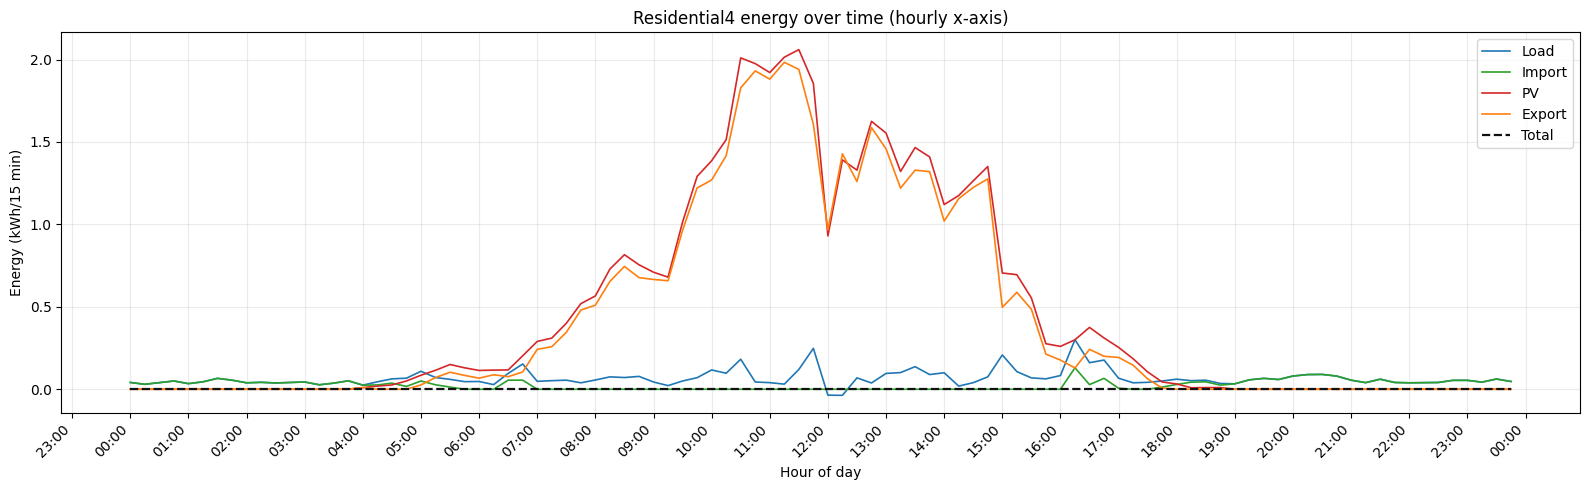

In [40]:
# plot residential1 load, import, and export over a long timeframe

import matplotlib.dates as mdates

# Support both stripped and original column naming conventions
col_candidates = {
    "Load": ["residential4_load"],
    "Import": ["residential4_grid_import"],
    "PV": ["residential4_pv"],
    "Export": ["residential4_grid_export"],
}

series_cols = {}
for label, candidates in col_candidates.items():
    series_cols[label] = next((c for c in candidates if c in df.columns), None)

available_cols = [c for c in series_cols.values() if c is not None]

plot_df = df[["utc_timestamp"] + available_cols].copy()
plot_df["utc_timestamp"] = pd.to_datetime(plot_df["utc_timestamp"], errors="coerce")
plot_df = plot_df.dropna(subset=["utc_timestamp"]).sort_values("utc_timestamp")

# plot timeframe only for one day in the summer to check if the data looks reasonable (should show 96 intervals for 15min data)
summer_df = plot_df[(plot_df["utc_timestamp"] >= "2016-06-01") & (plot_df["utc_timestamp"] < "2016-06-02")].copy()

# calculate total = import + pv - export - load
total_series = pd.Series(0.0, index=summer_df.index)
if series_cols["Import"] is not None:
    total_series = total_series + summer_df[series_cols["Import"]]
if series_cols["PV"] is not None:
    total_series = total_series + summer_df[series_cols["PV"]]
if series_cols["Export"] is not None:
    total_series = total_series - summer_df[series_cols["Export"]]
if series_cols["Load"] is not None:
    total_series = total_series - summer_df[series_cols["Load"]]
summer_df["Total"] = total_series

plt.figure(figsize=(16, 5))
colors = {"Load": "#1f77b4", "Import": "#2ca02c", "PV": "#d62728", "Export": "#ff7f0e", "Total": "#111111"}

for label in ["Load", "Import", "PV", "Export"]:
    col = series_cols[label]
    if col is None:
        plt.plot([], [], color=colors[label], label=f"{label} (missing)")
    else:
        plt.plot(summer_df["utc_timestamp"], summer_df[col], color=colors[label], linewidth=1.2, label=label)

plt.plot(summer_df["utc_timestamp"], summer_df["Total"], color=colors["Total"], linewidth=1.6, linestyle="--", label="Total")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.title("Residential4 energy over time (hourly x-axis)")
plt.xlabel("Hour of day")
plt.ylabel("Energy (kWh/15 min)")
plt.legend()
plt.grid(alpha=0.25)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


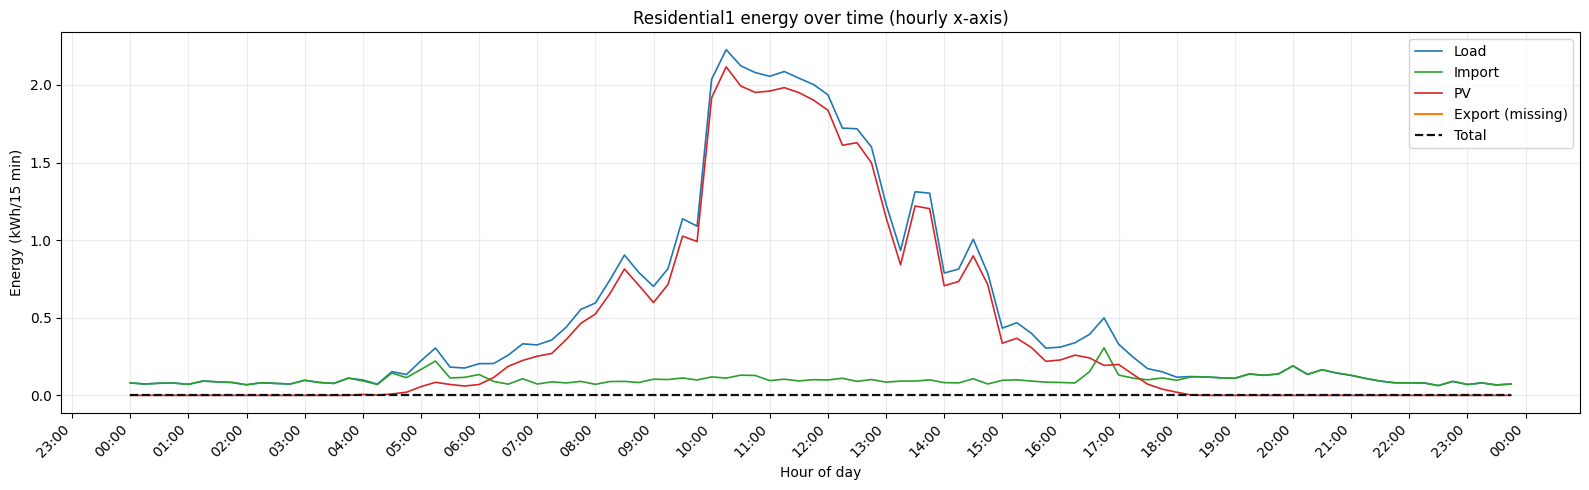

In [41]:
# plot residential1 load, import, and export over a long timeframe

import matplotlib.dates as mdates

# Support both stripped and original column naming conventions
col_candidates = {
    "Load": ["residential1_load"],
    "Import": ["residential1_grid_import"],
    "PV": ["residential1_pv"],
    "Export": ["residential1_grid_export"],
}

series_cols = {}
for label, candidates in col_candidates.items():
    series_cols[label] = next((c for c in candidates if c in df.columns), None)

available_cols = [c for c in series_cols.values() if c is not None]

plot_df = df[["utc_timestamp"] + available_cols].copy()
plot_df["utc_timestamp"] = pd.to_datetime(plot_df["utc_timestamp"], errors="coerce")
plot_df = plot_df.dropna(subset=["utc_timestamp"]).sort_values("utc_timestamp")

# plot timeframe only for one day in the summer to check if the data looks reasonable (should show 96 intervals for 15min data)
summer_df = plot_df[(plot_df["utc_timestamp"] >= "2016-06-01") & (plot_df["utc_timestamp"] < "2016-06-02")].copy()

# calculate total = import + pv - export - load
total_series = pd.Series(0.0, index=summer_df.index)
if series_cols["Import"] is not None:
    total_series = total_series + summer_df[series_cols["Import"]]
if series_cols["PV"] is not None:
    total_series = total_series + summer_df[series_cols["PV"]]
if series_cols["Export"] is not None:
    total_series = total_series - summer_df[series_cols["Export"]]
if series_cols["Load"] is not None:
    total_series = total_series - summer_df[series_cols["Load"]]
summer_df["Total"] = total_series

plt.figure(figsize=(16, 5))
colors = {"Load": "#1f77b4", "Import": "#2ca02c", "PV": "#d62728", "Export": "#ff7f0e", "Total": "#111111"}

for label in ["Load", "Import", "PV", "Export"]:
    col = series_cols[label]
    if col is None:
        plt.plot([], [], color=colors[label], label=f"{label} (missing)")
    else:
        plt.plot(summer_df["utc_timestamp"], summer_df[col], color=colors[label], linewidth=1.2, label=label)

plt.plot(summer_df["utc_timestamp"], summer_df["Total"], color=colors["Total"], linewidth=1.6, linestyle="--", label="Total")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.title("Residential1 energy over time (hourly x-axis)")
plt.xlabel("Hour of day")
plt.ylabel("Energy (kWh/15 min)")
plt.legend()
plt.grid(alpha=0.25)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
